In [199]:
# Import numpy
import numpy as np

# Import pandas for data handling
import pandas as pd

import os

# Import plotting libraries
import matplotlib
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

import seaborn as sns
sns.set('notebook', font_scale=1.25, style='whitegrid')

In [200]:
DATA_PATH = '.'
data_file = 'trial_results.csv'

In [201]:
if not os.path.exists(os.path.join(DATA_PATH, data_file)):
    try:
        DATA_PATH = os.path.join(os.environ.get("HOME", ""),
                    '/Users/juliasantaniello/Desktop/OfflineNeuroloop/src/results/')
        assert os.path.exists(os.path.join(DATA_PATH, data_file))
    except AssertionError:
        print("Please store path to results csv in DATA_PATH")

assert os.path.exists(os.path.join(DATA_PATH, data_file))

In [202]:
# Try to robustly read the CSV, attempt to handle extra columns due to trailing commas or malformed rows

PATH = '/Users/juliasantaniello/Desktop/OfflineNeuroloop/src/results/' + data_file

# Attempt 1: try regular read_csv, fallback to python engine if error, also skip bad lines if needed
try:
    df = pd.read_csv(PATH)
except pd.errors.ParserError:
    try:
        df = pd.read_csv(PATH, engine='python')
    except Exception:
        df = pd.read_csv(PATH, engine='python', on_bad_lines='skip')


In [203]:
results = df #pd.read_csv(os.path.join(DATA_PATH, 'trial_results.csv'))
# results['parameters_experiment_domain'] = results['parameters_experiment_domain'].replace({'lunar': 'Lunar Lander'})

In [204]:
results.columns

Index(['parameters_experiment_domain', 'parameters_experiment_task',
       'parameters_experiment_condition',
       'parameters_experiment_experiment_list',
       'parameters_experiment_model_granularity',
       'parameters_experiment_participant_list',
       'parameters_experiment_random_state',
       'parameters_experiment_pretrained_success_rate',
       'parameters_neural_smoothing_window_size',
       'parameters_neural_temporal_shift', 'parameters_neural_window_size_s',
       'parameters_neural_fnirs_rate_hz', 'parameters_neural_beta',
       'parameters_mlp_model_noise',
       'parameters_mlp_binary_hidden_layer_sizes',
       'parameters_mlp_ternary_hidden_layer_sizes',
       'parameters_mlp_regressor_hidden_layer_sizes',
       'parameters_mlp_clf_activation', 'parameters_mlp_reg_activation',
       'parameters_mlp_early_stopping', 'parameters_mlp_binary_alpha',
       'parameters_mlp_ternary_alpha', 'parameters_mlp_reg_alpha',
       'parameters_mlp_binary_activation

In [205]:
results.columns
to_plot = "results_success_rate"
# to_plot = "results_total_reward"
# to_plot = "results_steps"

In [206]:
results.iloc[0]

parameters_experiment_domain                                                               Passive
parameters_experiment_task                                                                Baseline
parameters_experiment_condition                                                                [0]
parameters_experiment_experiment_list                                                       binary
parameters_experiment_model_granularity          [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, ...
parameters_experiment_participant_list                                                          43
parameters_experiment_random_state                                                             0.0
parameters_experiment_pretrained_success_rate                                                False
parameters_neural_smoothing_window_size                                                          1
parameters_neural_temporal_shift                                                               0.0
parameters

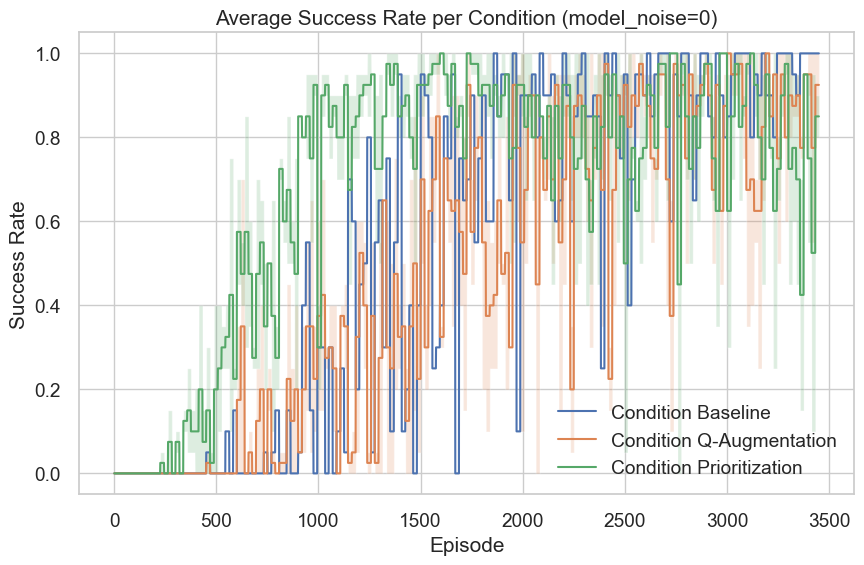

In [207]:
# Take each trial from results. Only plot/compare the condition trials where model_noise == 0
# For each condition, average success rate per episode across all trials (with std), then plot mean±std

import matplotlib.pyplot as plt
import numpy as np

# Only keep trials with model noise == 0 and temporal shift == 0 (if desired)
noise_zero = results[results['parameters_mlp_model_noise'] == 0]
noise_zero = noise_zero[noise_zero['parameters_neural_temporal_shift'] == 0]

unique_conditions = noise_zero['parameters_experiment_task'].unique()

success_rate_curves = {}

# Each row is a trial. Each row has a list (as string) of episode success rates.
for cond in unique_conditions:
    cond_trials = noise_zero[noise_zero['parameters_experiment_task'] == cond]
    trial_sr_lists = []
    min_len = None

    for val in cond_trials['results_success_rate']:
        if isinstance(val, str):
            arr = np.array(eval(val))
        elif isinstance(val, (list, np.ndarray)):
            arr = np.array(val)
        else:
            continue  # skip if not a list

        if min_len is None or len(arr) < min_len:
            min_len = len(arr)
        trial_sr_lists.append(arr)

    # Truncate all to minimum length for fair per-episode mean/std
    truncated = [x[:min_len] for x in trial_sr_lists if len(x) >= min_len]
    if len(truncated) > 0:
        stacked = np.vstack(truncated)  # shape: [n_trials, n_episodes]
        mean_curve = np.mean(stacked, axis=0)
        std_curve = np.std(stacked, axis=0)
        success_rate_curves[cond] = (mean_curve, std_curve)

plt.figure(figsize=(10, 6))
for cond, (mean_curve, std_curve) in success_rate_curves.items():
    episodes = np.arange(1, len(mean_curve) + 1)
    plt.plot(episodes, mean_curve, label=f'Condition {cond}')
    plt.fill_between(episodes, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2)

plt.xlabel('Episode')
plt.ylabel('Success Rate')
plt.title('Average Success Rate per Condition (model_noise=0)')
plt.legend()
plt.show()

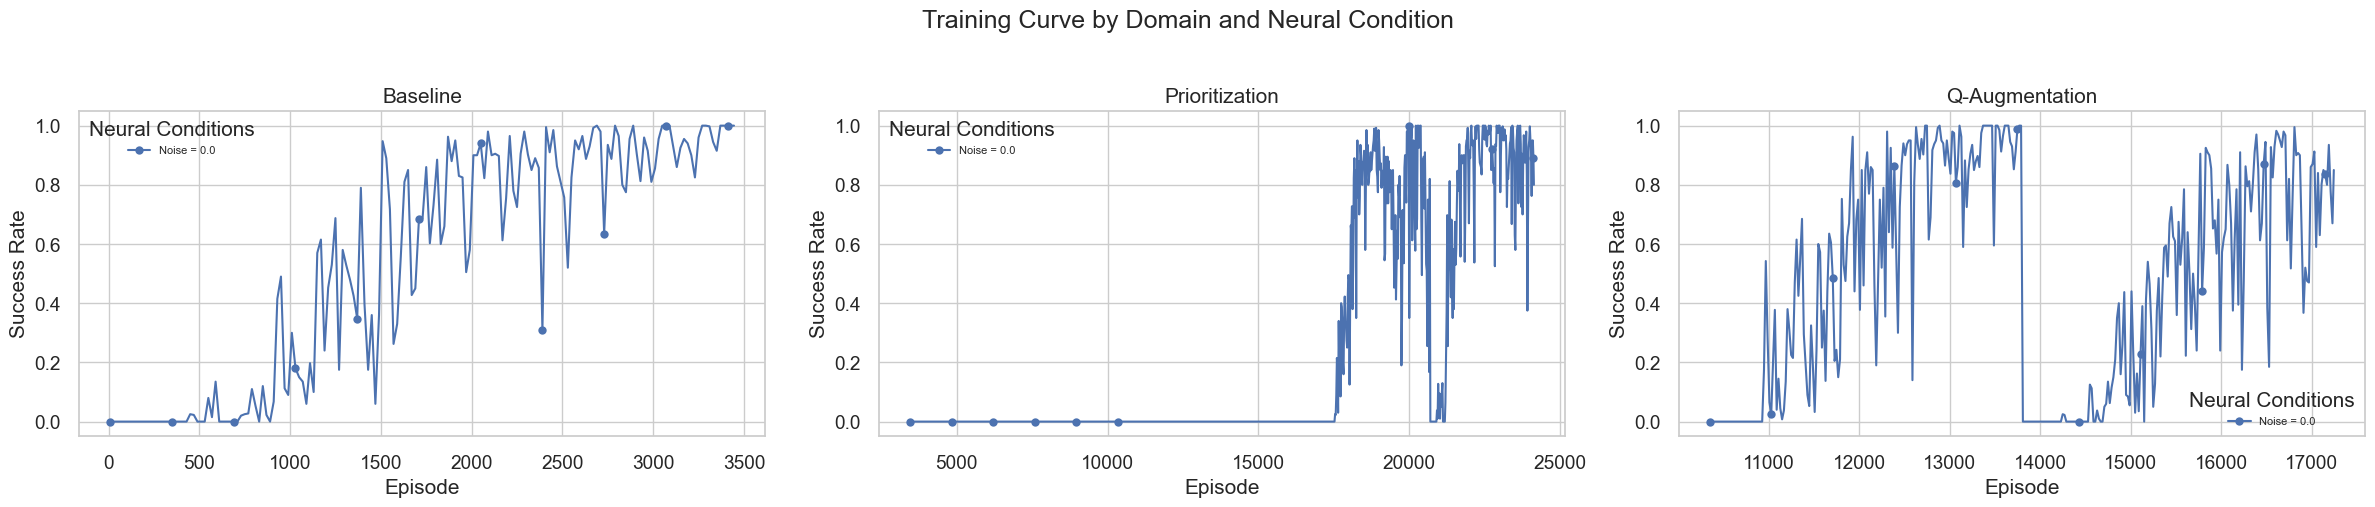

In [208]:
# Same series as the next cell (model noise); non-overlapping 10-episode bucket moving average
# on per-episode mean reward (std averaged within each bucket for the band).
BUCKET = 20

# Mask where temporal shift is greater than 0.0
filtered = exploded[exploded['parameters_neural_temporal_shift'] <= 0.0].copy()

grouped = filtered.groupby([
    'parameters_experiment_task',
    'parameters_mlp_model_noise',
    'episode',
])['reward_list'].agg(['mean', 'sem']).reset_index()

grouped['ep_bucket'] = grouped['episode'] // BUCKET
bucketed = (
    grouped.groupby(
        ['parameters_experiment_task', 'parameters_mlp_model_noise', 'ep_bucket'],
        as_index=False,
    )
    .agg(
        episode=('episode', 'mean'),
        mean=('mean', 'mean'),
        std=('sem', 'mean'),
    )
)

combos = bucketed[['parameters_experiment_task']].drop_duplicates()
n_plots = len(combos)

fig, axes = plt.subplots(1, n_plots, figsize=(8 * n_plots, 5), sharey=False)
if n_plots == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, combos.iterrows()):
    domain = row['parameters_experiment_task']
    subset = bucketed[bucketed['parameters_experiment_task'] == domain]

    for noise in sorted(subset['parameters_mlp_model_noise'].unique()):
        noise_data = subset[subset['parameters_mlp_model_noise'] == noise].sort_values('episode')
    
        episodes = noise_data['episode']
        mean = noise_data['mean']
        std = noise_data['std']

        line, = ax.plot(
            episodes,
            mean,
            marker='o',
            markevery=max(1, len(episodes) // 10),
            label=f'Noise = {noise}',
        )
        ax.fill_between(episodes, mean - std, mean + std, alpha=0.2, color=line.get_color())

    ax.set_title(f'{domain}')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Success Rate')
    ax.legend(title='Neural Conditions', fontsize=8)

fig.suptitle(
    f'Training Curve by Domain and Neural Condition',
    y=1.02,
)
plt.tight_layout()
plt.show()


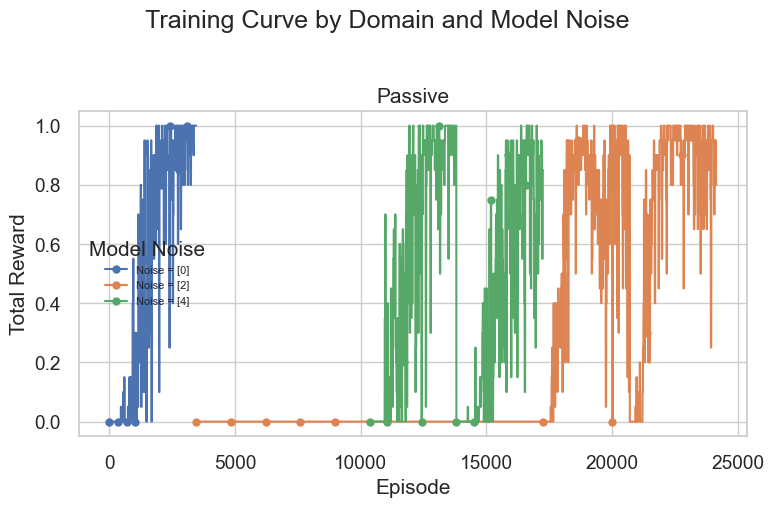

In [209]:
# Group by domain, noise, episode
grouped = exploded.groupby([
    'parameters_experiment_domain',
    'parameters_experiment_condition',
    'episode'
])['reward_list'].agg(['mean', 'sem']).reset_index()

# Get unique domain/task combos -- we would add parameters_experiment_task here if we wanted to also group by task
combos = grouped[['parameters_experiment_domain']].drop_duplicates()
n_plots = len(combos)

fig, axes = plt.subplots(1, n_plots, figsize=(8 * n_plots, 5), sharey=False)
if n_plots == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, combos.iterrows()):
    domain = row['parameters_experiment_domain']
    

    subset = grouped[
        (grouped['parameters_experiment_domain'] == domain)
    ]

    for noise in sorted(subset['parameters_experiment_condition'].unique()):
        noise_data = subset[subset['parameters_experiment_condition'] == noise].sort_values('episode')
        episodes = noise_data['episode']
        mean = noise_data['mean']
        std = noise_data['sem']
 
        line, = ax.plot(episodes, mean, marker='o', markevery=max(1, len(episodes)//10), label=f'Noise = {noise}')
        ax.fill_between(episodes, mean - std, mean + std, alpha=0.2, color=line.get_color())

    ax.set_title(f'{domain}')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.legend(title='Model Noise', fontsize=8)

fig.suptitle('Training Curve by Domain and Model Noise', y=1.02)
plt.tight_layout()
plt.show()

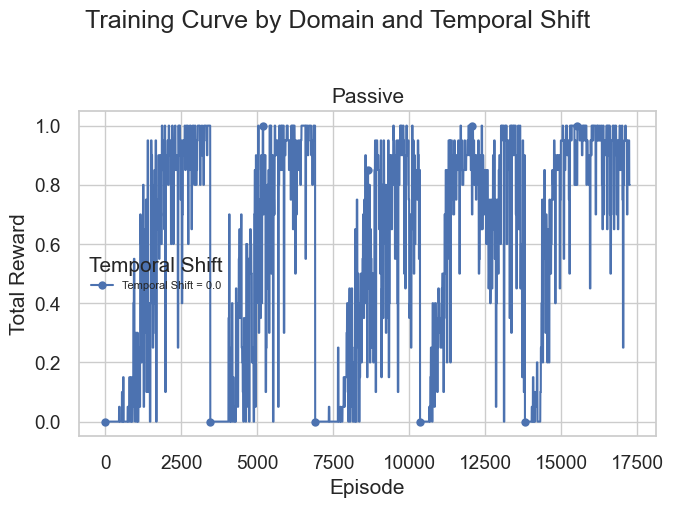

In [210]:
results['reward_list'] = results['results_success_rate'].apply(parse_rewards)

# Explode into per-episode rows
exploded = results.explode('reward_list').copy()
exploded['reward_list'] = exploded['reward_list'].astype(float)
exploded['episode'] = exploded.groupby(level=0)['reward_list'].cumcount()

# Group by domain, shift, episode
grouped = exploded.groupby([
    'parameters_experiment_domain',
    'parameters_neural_temporal_shift',
    'episode'
])['reward_list'].agg(['mean', 'std']).reset_index()

# Get unique domain/task combos
combos = grouped[['parameters_experiment_domain']].drop_duplicates()
n_plots = len(combos)

fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5), sharey=False)
if n_plots == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, combos.iterrows()):
    domain = row['parameters_experiment_domain']
    

    subset = grouped[
        (grouped['parameters_experiment_domain'] == domain)
    ]

    for shift in sorted(subset['parameters_neural_temporal_shift'].unique()):
        shift_data = subset[subset['parameters_neural_temporal_shift'] == shift].sort_values('episode')
        episodes = shift_data['episode']
        mean = shift_data['mean']
        std = shift_data['std']
 
        line, = ax.plot(episodes, mean, marker='o', markevery=max(1, len(episodes)//10), label=f'Temporal Shift = {shift}')
        ax.fill_between(episodes, mean - std, mean + std, alpha=0.2, color=line.get_color())

    ax.set_title(f'{domain}')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.legend(title='Temporal Shift', fontsize=8)

fig.suptitle('Training Curve by Domain and Temporal Shift', y=1.02)
plt.tight_layout()
plt.show()

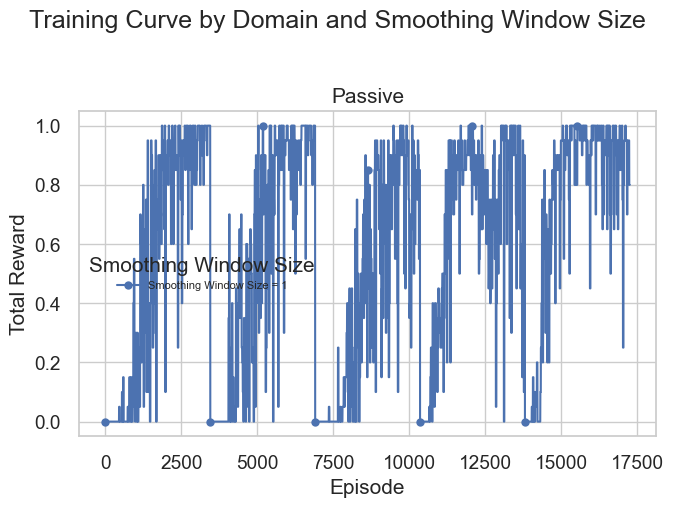

In [211]:
# Group by domain, smoothing window size, episode
grouped = exploded.groupby([
    'parameters_experiment_domain',
    'parameters_neural_smoothing_window_size',
    'episode'
])['reward_list'].agg(['mean', 'std']).reset_index()

# Get unique domain/task combos
combos = grouped[['parameters_experiment_domain']].drop_duplicates()
n_plots = len(combos)

fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5), sharey=False)
if n_plots == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, combos.iterrows()):
    domain = row['parameters_experiment_domain']
    

    subset = grouped[
        (grouped['parameters_experiment_domain'] == domain)
    ]

    for window_size in sorted(subset['parameters_neural_smoothing_window_size'].unique()):
        window_size_data = subset[subset['parameters_neural_smoothing_window_size'] == window_size].sort_values('episode')
        episodes = window_size_data['episode']
        mean = window_size_data['mean']
        std = window_size_data['std']
 
        line, = ax.plot(episodes, mean, marker='o', markevery=max(1, len(episodes)//10), label=f'Smoothing Window Size = {window_size}')
        ax.fill_between(episodes, mean - std, mean + std, alpha=0.2, color=line.get_color())

    ax.set_title(f'{domain}')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.legend(title='Smoothing Window Size', fontsize=8)

fig.suptitle('Training Curve by Domain and Smoothing Window Size', y=1.02)
plt.tight_layout()
plt.show()

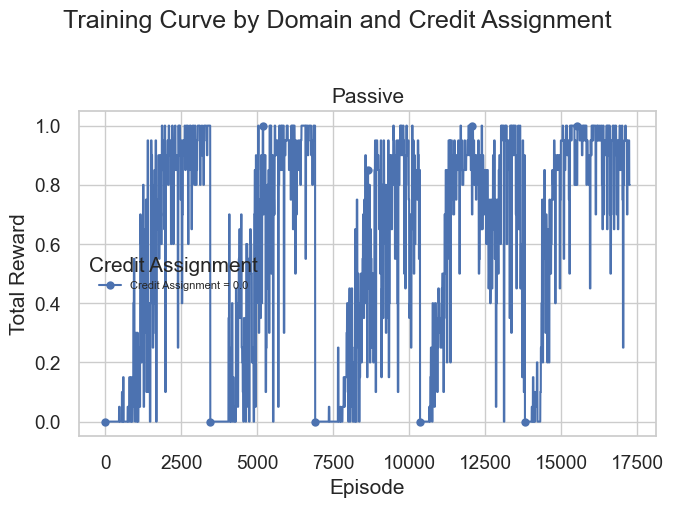

In [212]:
# Group by domain, credit assignment, episode
grouped = exploded.groupby([
    'parameters_experiment_domain',
    'parameters_neural_temporal_shift',
    'episode'
])['reward_list'].agg(['mean', 'std']).reset_index()

# Get unique domain/task combos
combos = grouped[['parameters_experiment_domain']].drop_duplicates()
n_plots = len(combos)

fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5), sharey=False)
if n_plots == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, combos.iterrows()):
    domain = row['parameters_experiment_domain']
    

    subset = grouped[
        (grouped['parameters_experiment_domain'] == domain)
    ]

    for credit_assignment in sorted(subset['parameters_neural_temporal_shift'].unique()):
        credit_assignment_data = subset[subset['parameters_neural_temporal_shift'] == credit_assignment].sort_values('episode')
        episodes = credit_assignment_data['episode']
        mean = credit_assignment_data['mean']
        std = credit_assignment_data['std']
 
        line, = ax.plot(episodes, mean, marker='o', markevery=max(1, len(episodes)//10), label=f'Credit Assignment = {credit_assignment}')
        ax.fill_between(episodes, mean - std, mean + std, alpha=0.2, color=line.get_color())

    ax.set_title(f'{domain}')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.legend(title='Credit Assignment', fontsize=8)

fig.suptitle('Training Curve by Domain and Credit Assignment', y=1.02)
plt.tight_layout()
plt.show()

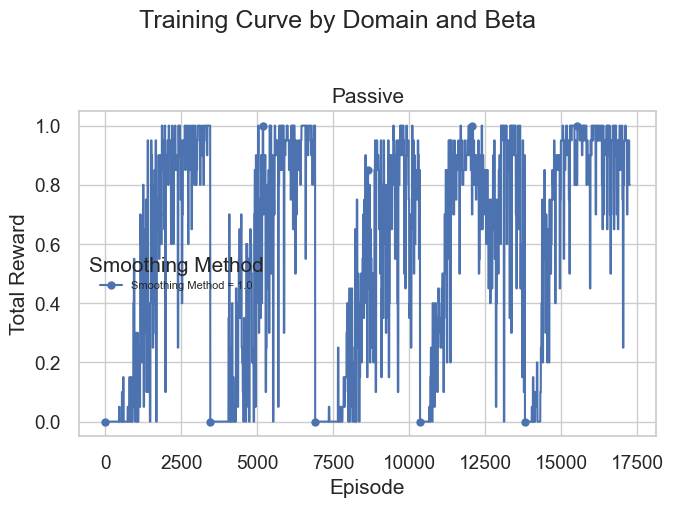

In [213]:
# Group by domain, smoothing method, episode
grouped = exploded.groupby([
    'parameters_experiment_domain',
    'parameters_neural_beta',
    'episode'
])['reward_list'].agg(['mean', 'std']).reset_index()

# Get unique domain/task combos
combos = grouped[['parameters_experiment_domain']].drop_duplicates()
n_plots = len(combos)

fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5), sharey=False)
if n_plots == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, combos.iterrows()):
    domain = row['parameters_experiment_domain']
    

    subset = grouped[
        (grouped['parameters_experiment_domain'] == domain)
    ]

    for smoothing_method in sorted(subset['parameters_neural_beta'].unique()):
        smoothing_method_data = subset[subset['parameters_neural_beta'] == smoothing_method].sort_values('episode')
        episodes = smoothing_method_data['episode']
        mean = smoothing_method_data['mean']
        std = smoothing_method_data['std']
 
        line, = ax.plot(episodes, mean, marker='o', markevery=max(1, len(episodes)//10), label=f'Smoothing Method = {smoothing_method}')
        ax.fill_between(episodes, mean - std, mean + std, alpha=0.2, color=line.get_color())

    ax.set_title(f'{domain}')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.legend(title='Smoothing Method', fontsize=8)

fig.suptitle('Training Curve by Domain and Beta', y=1.02)
plt.tight_layout()
plt.show()